Create a fresh notebook/script and implement the entire single-feature linear regression workflow from scratch:

Create x and y

Implement predict()

Test predictions

Implement compute_cost()

Test cost

Implement compute_gradient()

Implement gradient_descent()

Train the model

Print final w and b

Generate predictions using the trained parameters

Plot actual data + prediction line

Plot cost history

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create the data

x = np.array([1200, 1800, 2500])
y = np.array([200000, 300000, 400000])

In [3]:
# Implement predict()

def predict(x, w, b):
    return w * x + b

In [4]:
# Test:

w = 150
b = 40000

predictions = predict(x, w, b)

print("Predictions:", predictions)

Predictions: [220000 310000 415000]


In [5]:
# Implement compute_cost()

def compute_cost(x, y, w, b):
    m = len(x)

    predictions = predict(x, w, b)
    errors = predictions - y

    cost = (1 / (2 * m)) * np.sum(errors ** 2)

    return cost

In [6]:
# Test:

cost = compute_cost(x, y, w, b)

print("Cost:", cost)

Cost: 120833333.33333333


In [7]:
# Implement compute_gradient()

def compute_gradient(x, y, w, b):
    m = len(x)

    predictions = predict(x, w, b)
    errors = predictions - y

    dj_dw = (1 / m) * np.sum(errors * x)
    dj_db = (1 / m) * np.sum(errors)

    return dj_dw, dj_db

In [8]:
# Test:

dj_dw, dj_db = compute_gradient(x, y, w, b)

print("dj_dw:", dj_dw)
print("dj_db:", dj_db)

dj_dw: 26500000.0
dj_db: 15000.0


In [9]:
# Implement gradient_descent()

def gradient_descent(x, y, w, b, alpha, num_iters):

    cost_history = []

    for i in range(num_iters):

        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

    return w, b, cost_history

In [10]:
# Train the model

w_init = 150
b_init = 40000

alpha = 1e-9
num_iters = 1000

In [11]:
# Train:

w_final, b_final, cost_history = gradient_descent(
    x,
    y,
    w_init,
    b_init,
    alpha,
    num_iters
)

print("Final w:", w_final)
print("Final b:", b_final)

Final w: 142.91549379391924
Final b: 39999.994769919336


In [12]:
# Generate predictions using trained parameters

predictions_final = predict(x, w_final, b_final)

print("Final predictions:", predictions_final)

Final predictions: [211498.58732262 297247.88359897 397288.72925472]


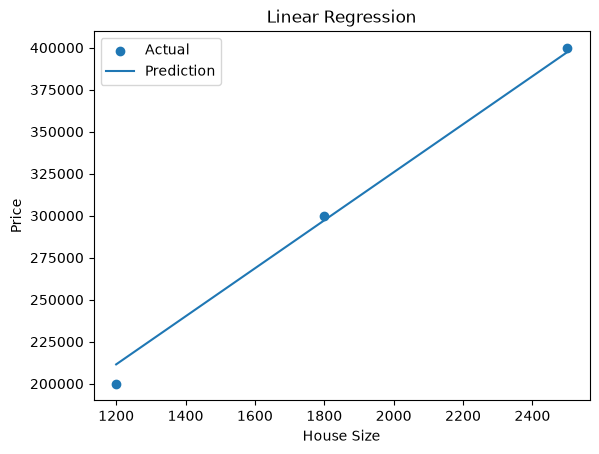

In [13]:
# Plot actual data + prediction line

plt.scatter(x, y, label="Actual")

plt.plot(
    x,
    predictions_final,
    label="Prediction"
)

plt.xlabel("House Size")
plt.ylabel("Price")
plt.title("Linear Regression")

plt.legend()
plt.show()

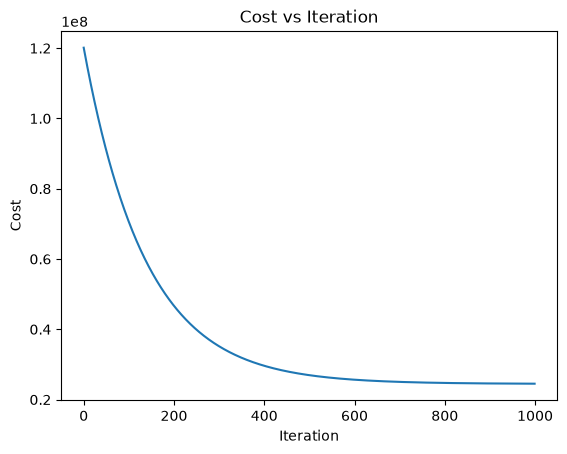

In [14]:
# Plot cost history

plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")

plt.show()